In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# REAL DATA

### LAEGERN

In [4]:
path_train = "../data/real_data/laegern_train.csv"
path_extrapolate = "../data/real_data/laegern_extrapolation.csv"

In [ ]:
# merge train and extrapolation data
train_data = pd.read_csv(path_train)    
extrapolate_data = pd.read_csv(path_extrapolate)
pred_data = pd.concat([train_data, extrapolate_data], ignore_index=True)

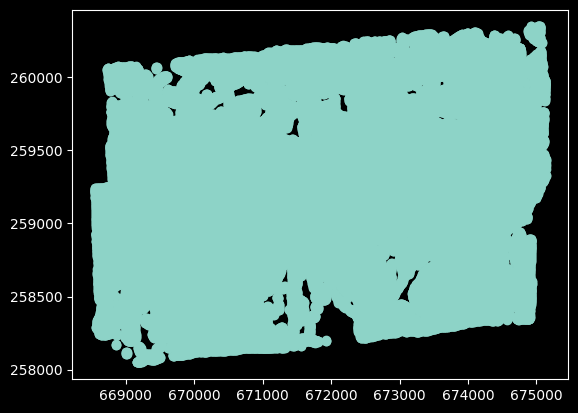

In [8]:
plt.scatter(pred_data['x_coord'], pred_data['y_coord'],)

In [10]:
# keep only necessary columns, and Y as first
pred_data = pred_data[["CanopyHeight", 'x_coord', 'y_coord']]

# save processed data
pred_data.to_csv("../data/real_data/laegern.csv", index=False)

### HEATHON

In [12]:
path_train = "../data/real_data/Heaton_train.csv"
path_test = "../data/real_data/Heaton_test.csv"
# load train and test data
train_data = pd.read_csv(path_train)    
test_data = pd.read_csv(path_test)

In [20]:
train_data.head()

,Lon,Lat,TrueTemp
0,-95.855886,37.068111,42.39
1,-95.846612,37.068111,41.85
2,-95.837338,37.068111,42.53
3,-95.828064,37.068111,45.27
4,-95.818790,37.068111,46.09


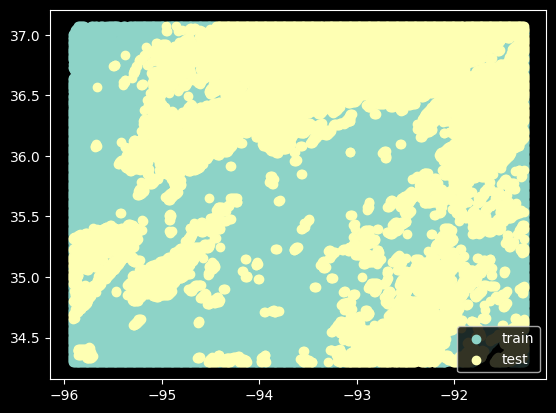

In [17]:
train_data.head()
plt.scatter(train_data['Lon'], train_data['Lat'], label = "train")
plt.scatter(test_data['Lon'], test_data['Lat'], label = "test")
plt.legend()

In [ ]:
# merge train and test data
pred_data = pd.concat([train_data, test_data], ignore_index=True)
pred_data = pred_data[["TrueTemp", "Lon", "Lat"]]

# save processed data
pred_data.to_csv("../data/real_data/heaton.csv", index=False)

### MODIS

In [24]:
path_train = "../data/real_data/MODIS_data_train.txt"
path_test = "../data/real_data/MODIS_data_test.txt"

In [45]:
# read txt files
train_data = pd.read_csv(path_train, sep = " ",)
test_data = pd.read_csv(path_test, sep = " ",)

In [46]:
train_data.head()

,east,north,temp
1,-8.371597e+06,4.300932e+06,38.33
2,-8.284495e+06,4.171204e+06,33.83
3,-8.575455e+06,3.960860e+06,31.97
4,-8.229824e+06,4.274060e+06,36.93
5,-7.980562e+06,3.676386e+06,30.25


c:\Users\JumpStart\Documents\environments\latest\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\JumpStart\Documents\environments\latest\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


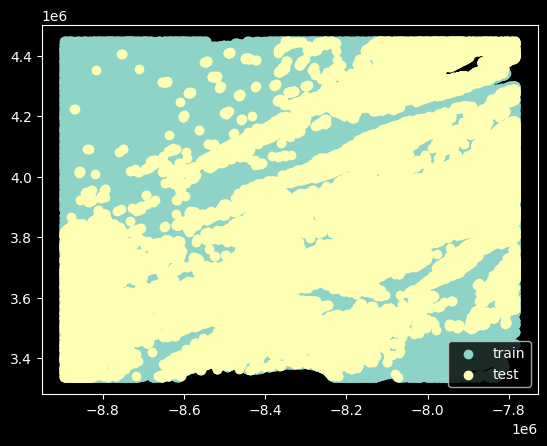

In [49]:
plt.scatter(train_data['east'], train_data['north'], label = "train")
plt.scatter(test_data['east'], test_data['north'], label = "test")
plt.legend()

In [51]:
# merge train and test data
pred_data = pd.concat([train_data, test_data], ignore_index=True)
pred_data = pred_data[["temp", "east", "north"]]
pred_data.head()

,temp,east,north
0,38.33,-8.371597e+06,4.300932e+06
1,33.83,-8.284495e+06,4.171204e+06
2,31.97,-8.575455e+06,3.960860e+06
3,36.93,-8.229824e+06,4.274060e+06
4,30.25,-7.980562e+06,3.676386e+06


In [52]:
# save processed data
pred_data.to_csv("../data/real_data/modis.csv", index=False)

### House

In [55]:
path_train = "../data/real_data/house_train.csv"
path_test = "../data/real_data/house_extrapolation.csv"

In [56]:
# laod train and test data
train_data = pd.read_csv(path_train)
test_data = pd.read_csv(path_test)        

In [58]:
train_data.head()

,long,lat,log_price
0,508605.945922,220581.671030,10.431170
1,511746.927365,223493.297045,10.819778
2,508113.884844,215728.749324,11.599103
3,506941.119664,222805.198566,11.938193
4,508274.059946,225483.266473,10.839581


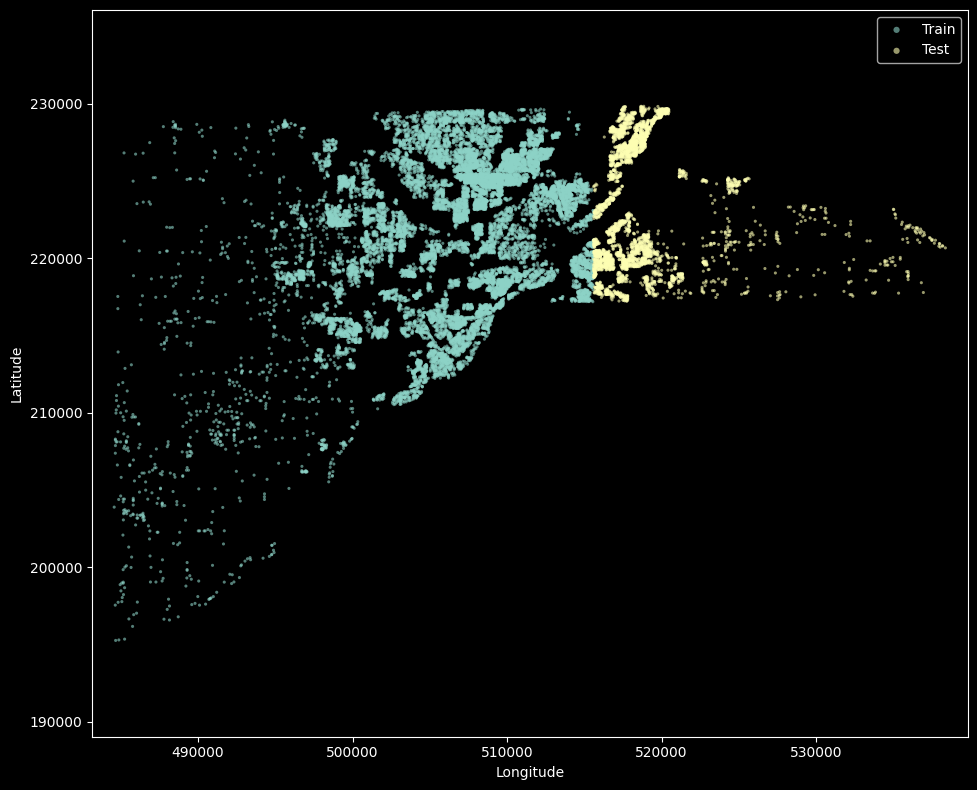

: 

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(train_data['long'], train_data['lat'], 
           s=5, alpha=0.6, label='Train', edgecolors='none')
plt.scatter(test_data['long'], test_data['lat'], 
           s=5, alpha=0.6, label='Test', edgecolors='none')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(markerscale=2)
plt.axis('equal')  # Keep aspect ratio for maps
plt.tight_layout()

In [60]:
# merge train and extrapolation data
pred_data = pd.concat([train_data, test_data], ignore_index=True)
pred_data = pred_data[["log_price", "long", "lat"]]

In [61]:
# save processed data
pred_data.to_csv("../data/real_data/house.csv", index=False)

In [95]:
path = "../data/real_data/house.csv"
data = pd.read_csv(path)
data.shape

(21554, 3)

# Crossed RE

Use cars as template for ratings.

In [7]:
path = "../data/real_data_mm/cars_crossed_preprocessed.npz"
data =  np.load(path)

In [8]:
data.keys()

KeysView(NpzFile '../data/real_data_mm/cars_crossed_preprocessed.npz' with keys: X, group_data, Y)

In [47]:
df_group = pd.DataFrame(data["group_data"]).add_prefix("m")
df = pd.concat([
    pd.DataFrame({"Y": data["Y"]}),
    pd.DataFrame(data["X"]).add_prefix("X"),
    pd.DataFrame(data["group_data"]).add_prefix("m")
], axis=1)
df_group.head()

,m0,m1
0,12164,1655
1,12400,1655
2,12439,1655
3,14211,1655
4,12250,1655


In [51]:
# Suppose factors are "A" and "B"
pairs = df_group.drop_duplicates()
# sample 10% of pairs
sampled_pairs = pairs.sample(frac=0.1, random_state=123)
# join back to get rows
df_small = df.merge(sampled_pairs, on=["m0", "m1"], how="inner")
print(df_small.shape)
print(df.shape)

(9712, 6)
(97729, 6)


In [49]:
df_small.head()

,Y,X0,X1,X2,m0,m1
0,10.025263,1.0,0.678299,0.39508,227,1655
1,10.373179,1.0,1.105521,0.16594,11754,1655
2,10.260812,1.0,0.963114,0.18531,11754,1655
3,9.902987,1.0,0.393484,0.96003,11002,1655
4,9.679719,1.0,0.535892,0.29652,2399,1655


In [59]:
# save small
np.savez('../data/real_data_mm/small_cars_preprocessed.npz',
        X=df_small[["X0", "X1", "X2"]].to_numpy(), 
        group_data=df_small[["m0", "m1"]].to_numpy(),
        Y=df_small["Y"].to_numpy())

In [60]:
# load back
data = np.load('../data/real_data_mm/small_cars_preprocessed.npz')

In [61]:
# now also for ratings
path = "../data/real_data_mm/ratings_preprocessed.npz"
data =  np.load(path)

df_group = pd.DataFrame(data["group_data"]).add_prefix("m")
df = pd.concat([
    pd.DataFrame({"Y": data["Y"]}),
    pd.DataFrame(data["X"]).add_prefix("X"),
    pd.DataFrame(data["group_data"]).add_prefix("m")
], axis=1)
df_group.head()

# Suppose factors are "A" and "B"
pairs = df_group.drop_duplicates()
# sample 10% of pairs
sampled_pairs = pairs.sample(frac=0.1, random_state=123)
# join back to get rows
df_small = df.merge(sampled_pairs, on=["m0", "m1"], how="inner")
print(df_small.shape)
print(df.shape)

(10084, 4)
(100836, 4)


In [62]:
df_small.head()

,Y,X0,m0,m1
0,4.0,1.0,0,5
1,4.0,1.0,0,632
2,3.0,1.0,0,787
3,5.0,1.0,0,827
4,5.0,1.0,0,897


In [63]:
# save small
np.savez('../data/real_data_mm/small_ratings_preprocessed.npz',
        X=df_small[["X0"]].to_numpy(), 
        group_data=df_small[["m0", "m1"]].to_numpy(),
        Y=df_small["Y"].to_numpy())

In [71]:
path = "../data/real_data_mm/ratings.csv"
data =  pd.read_csv(path)

In [ ]:
data.rating.nunique()

10

In [63]:
data.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [64]:
Y = data["rating"]
X = np.ones((len(Y), 1))
group_data = data.loc[:, ["userId", "movieId"]]

In [65]:
X.shape

(100836, 1)

In [66]:
# Convert categorical variables to numeric factor-like codes
group_data = group_data.apply(lambda col: col.astype("category").cat.codes)

# If you need it as a NumPy array (like the R matrix)
group_data_np = group_data.to_numpy()

In [67]:
X.min(axis=0)[False]

array([], shape=(0, 1), dtype=float64)

In [ ]:
np.savez('../data/real_data_mm/ratings_preprocessed.npz',
         X=X, group_data=group_data_np, Y=Y)


In [15]:
len(np.unique(data["group_data"]))

15226

In [115]:
group1 = pd.get_dummies(data["group_data"][:,0], drop_first=True, dtype=int)

In [127]:
(group1 == 1).sum().sum()

np.int64(97728)

In [116]:
group2 = pd.get_dummies(data["group_data"][:,1], drop_first=True, dtype=int)

In [119]:
group2.shape

(97729, 12234)

In [124]:
Z = pd.concat([group1, group2], axis=1)

MemoryError: Unable to allocate 11.1 GiB for an array with shape (15225, 97729) and data type int64

In [99]:
PATH = "../data/real_data_mm/cars.csv"

In [100]:
my_data = pd.read_csv(PATH)

In [101]:
my_data.head()

,price,year,odometer,lat,long,model_id,location_id,manufacturerbmw,manufacturerchevrolet,manufacturerdodge,...,paint_colorcustom,paint_colorgreen,paint_colorgrey,paint_color_na,paint_colororange,paint_colorpurple,paint_colorred,paint_colorsilver,paint_colorwhite,paint_coloryellow
0,33590,0.251077,0.57923,-3.416363,3.749557,12164,1655,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,22590,-0.318553,0.71229,-3.416363,3.749557,12400,1655,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,39590,1.105521,0.19160,-3.416363,3.749557,12439,1655,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,30990,0.678299,0.41124,-3.416363,3.749557,14211,1655,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,27990,-0.033738,0.68696,-3.416363,3.749557,12250,1655,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [102]:
my_data["model_id"].nunique()

15226

In [103]:
my_data["location_id"].nunique()

12235

In [104]:
my_data.shape


(97729, 78)

In [68]:
# Categorical variables
cat_vars = ["model_id"] #, "location_id"]
group_data_df = my_data[cat_vars]

# Convert categorical variables to numeric factor-like codes
group_data = group_data_df.apply(lambda col: col.astype("category").cat.codes)

# If you need it as a NumPy array (like the R matrix)
group_data_np = group_data.to_numpy()

# Drop target and specified dummy columns
included_cols = ["year", "odometer"]
feat_cols = [col for col in my_data.columns if col in included_cols]
X = my_data[feat_cols].to_numpy()
# Add intercept term
intercept = np.ones((X.shape[0], 1))
X = np.hstack([intercept, X])        
# Response
Y = np.log(my_data["price"].to_numpy())

In [79]:
np.isnan(X).sum(), np.isinf(X).sum(), np.isnan(Y).sum(), np.isinf(Y).sum()

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

In [69]:
X.shape

(97729, 3)

In [64]:
Y = data['price']
X = data.drop(columns=["distance", "Subject"])
X
groups = data['Subject']

KeyError: "['distance', 'Subject'] not found in axis"

In [51]:
# dummy encode the categorical variable
X = pd.get_dummies(X, drop_first=True, dtype=int)

In [52]:
X

,age,Sex_Male
0,8,1
1,10,1
2,12,1
3,14,1
4,8,1
...,...,...
103,14,0
104,8,0
105,10,0
106,12,0


In [89]:
path = "../data/real_data_mm/cars_preprocessed.npz"
data = np.load(path)
data

NpzFile '../data/real_data_mm/cars_preprocessed.npz' with keys: X, group_data, Y

In [90]:
data["group_data"].shape

(97729, 1)

In [91]:
len(np.unique(data["group_data"]))

15226

In [74]:
print(data.shape)

(3, 1)


In [ ]:
# NP SAVE AS PREPROCESSED DATA

In [20]:
path = "../results/simulation_mm/One_random_effect/021/simulation_results_python.pkl"

In [21]:
import pickle
with open(path, 'rb') as f:
    results = pickle.load(f)

In [22]:
results

{'config': {'data_generation': {'n_groups': [10],
   'group_size': [10],
   'n_groups_2': 100,
   'signal_variance': 1.0,
   'signal_variance_2': 2.0,
   'fixed_snr': True,
   'snr': 5.0,
   'quantile': 0.8,
   'likelihood': ['ald', 'gaussian'],
   'pars': {'gaussian': {'scale': np.float64(0.4472135954999579)},
    'ald': {'q': 0.8, 'scale': np.float64(0.08677218312746245)},
    't': {'df': 3, 'scale': np.float64(0.31622776601683794)},
    'chi': {'df': 1, 'scale': 1}},
   'replicate': 10,
   'test_size': 0.25,
   'randeff': 'One_random_effect',
   'output_folder': 'simulated_data_mm',
   'random_state': 123,
   'extrapolate': False,
   'num_covariates': 5,
   'has_F': False,
   'factor_m2': 1.0,
   'sigma2': 0.25,
   'sigma2_1': 0.25,
   'sigma2_2': 0.25,
   'sigma2_3': 0.25},
  'models': ['gpboost_normal',
   'gpboost_cc',
   'gpboost_lls',
   'gpboost_lls_freq',
   'gpboost_fisher',
   'gpboost_lls_v2',
   'gpboost_lls_v2_freq',
   'gpboost_cc_var_corr',
   'gpboost_lls_groups',
   